In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import StringType, FloatType
from pyspark.ml.feature import Tokenizer, Word2Vec, PCA, PCAModel
from pyspark.ml.clustering import KMeans, KMeansModel
from pyspark.ml.evaluation import ClusteringEvaluator
from nltk.corpus import stopwords
from langdetect import detect, DetectorFactory
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from kneed import KneeLocator
import pyspark.sql.functions as F
from numpy import dot
from numpy.linalg import norm

In [2]:
# New Spark configuration
spark = SparkSession.builder.appName('BDClustering') \
    .config("spark.sql.shuffle.partitions", "100") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.executor.cores", "4") \
    .config("spark.task.cpus", "4") \
    .config("spark.driver.maxResultSize", "8g") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/06/09 17:23:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/06/09 17:23:07 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [3]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

custom_stop_words = set(['doi', 'preprint', 'copyright', 'peer', 'reviewed', 'org', 'https', 'et', 'al', 'author',
                         'figure', 'rights', 'reserved', 'permission', 'used', 'using', 'biorxiv', 'medrxiv', 'license',
                         'fig', 'fig.', 'al.', 'Elsevier', 'PMC', 'CZI', 'www'])
all_stop_words = stop_words.union(custom_stop_words)

DetectorFactory.seed = 0

def detect_language(text):
    if text is None:
        return None
    try:
        return detect(text)
    except:
        return None

def preprocess_text(text):
    if text is None:
        return None
    text = text.lower()
    text = re.sub(r'[!()-[\]{};:"\\,<>./?@#$%^&*_~]', ' ', text)
    words = text.split()
    filtered_words = [word for word in words if word not in all_stop_words]
    return ' '.join(filtered_words)

detect_language_udf = udf(detect_language, StringType())
preprocess_text_udf = udf(preprocess_text, StringType())

# Load data
file_paths = [
    '/gpfs/space/home/alikhano/bigdata/data/dblp-ref-0.json',
    # '/gpfs/space/home/alikhano/bigdata/data/dblp-ref-1.json',
    # '/gpfs/space/home/alikhano/bigdata/data/dblp-ref-2.json',
    # '/gpfs/space/home/alikhano/bigdata/data/dblp-ref-3.json',
]

df = spark.read.json(file_paths)
df = df.limit(1000)
df = df.withColumn("language", detect_language_udf(col("abstract")))
df = df.filter(col("language") == "en").drop("language")

df = df.withColumn("abstract", preprocess_text_udf(col("abstract")))

# Cache DataFrame after preprocessing
df.cache()

df.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /gpfs/space/home/alikhano/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+
|            abstract|             authors|                  id|n_citation|          references|               title|               venue|year|
+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+
|purpose study dev...|[Makoto Satoh, Ry...|00127ee2-cb05-48c...|         0|[51c7e02e-f5ed-43...|Preliminary Desig...|international con...|2013|
|paper describes d...|[Gareth Beale, Gr...|001c58d3-26ad-46b...|        50|[10482dd3-4642-41...|A methodology for...|visual analytics ...|2011|
|article applied g...|[Altaf Hossain, F...|001c8744-73c4-4b0...|        50|[2d84c0f2-e656-4c...|Comparison of GAR...|pattern recogniti...|2009|
|recent achievemen...|[Ankita Brahmacha...|00a119c4-d367-460...|         0|[84d47128-58d0-41...|Identifying Psych...|                   

In [4]:
tokenizer = Tokenizer(inputCol="abstract", outputCol="words")
df = tokenizer.transform(df)

word2Vec = Word2Vec(vectorSize=10, minCount=1, inputCol="words", outputCol="word_vectors")
model = word2Vec.fit(df)

df = model.transform(df)

# Cache DataFrame after word2Vec transformation
df.cache()

24/06/09 17:23:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


DataFrame[abstract: string, authors: array<string>, id: string, n_citation: bigint, references: array<string>, title: string, venue: string, year: bigint, words: array<string>, word_vectors: vector]

In [17]:
df = df.drop("pca_features")
df.cache()
df.show()

+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+
|            abstract|             authors|                  id|n_citation|          references|               title|               venue|year|               words|        word_vectors|
+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+
|purpose study dev...|[Makoto Satoh, Ry...|00127ee2-cb05-48c...|         0|[51c7e02e-f5ed-43...|Preliminary Desig...|international con...|2013|[purpose, study, ...|[-0.0618994666162...|
|paper describes d...|[Gareth Beale, Gr...|001c58d3-26ad-46b...|        50|[10482dd3-4642-41...|A methodology for...|visual analytics ...|2011|[paper, describes...|[-0.0310619319746...|
|article applied g...|[Altaf Hossain, F...|001c8744-73c4-4b0...|      

In [18]:

pca = PCA(k=10, inputCol="word_vectors", outputCol="pca_features")
pca_model = pca.fit(df)
df = pca_model.transform(df)

# Cache DataFrame after PCA transformation
df.cache()

explained_variance = pca_model.explainedVariance.cumsum()
num_components = np.argmax(explained_variance >= 0.95) + 1
df = df.drop("pca_features")
df.cache()
pca = PCA(k=num_components, inputCol="word_vectors", outputCol="pca_features")
pca_model = pca.fit(df)
df = pca_model.transform(df)

In [19]:
df.show()

+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+--------------------+
|            abstract|             authors|                  id|n_citation|          references|               title|               venue|year|               words|        word_vectors|        pca_features|
+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+--------------------+
|purpose study dev...|[Makoto Satoh, Ry...|00127ee2-cb05-48c...|         0|[51c7e02e-f5ed-43...|Preliminary Desig...|international con...|2013|[purpose, study, ...|[-0.0618994666162...|[0.10821295918360...|
|paper describes d...|[Gareth Beale, Gr...|001c58d3-26ad-46b...|        50|[10482dd3-4642-41...|A methodology for...|visual analytics ...|2011|[paper, describes...|[-0.0310

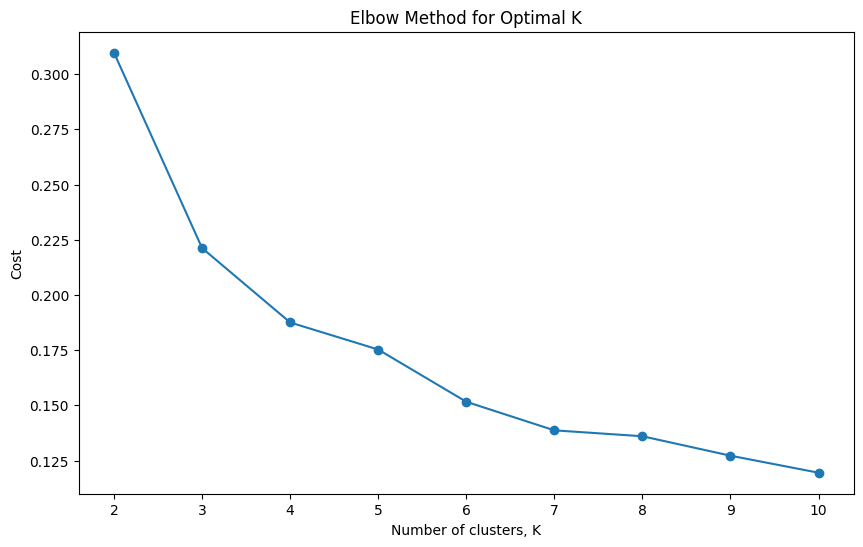

In [21]:
cost = []
k_values = range(2, 11)

for k in k_values:
    # Repartition the DataFrame before KMeans
    df_repartitioned = df.repartition(100)
    kmeans = KMeans(featuresCol="pca_features", k=k, seed=1)
    model = kmeans.fit(df_repartitioned)
    cost.append(model.summary.trainingCost)

plt.figure(figsize=(10, 6))
plt.plot(k_values, cost, marker='o')
plt.xlabel('Number of clusters, K')
plt.ylabel('Cost')
plt.title('Elbow Method for Optimal K')
plt.show()

In [24]:
knee = KneeLocator(k_values, cost, curve='convex', direction='decreasing')
optimal_k = knee.knee

print(f'The optimal number of clusters is: {optimal_k}')

df_repartitioned = df.repartition(100)
kmeans = KMeans(featuresCol="pca_features", k=optimal_k, seed=1)
kmeans_model = kmeans.fit(df_repartitioned)

predictions = kmeans_model.transform(df_repartitioned)

evaluator = ClusteringEvaluator(featuresCol="pca_features")
silhouette = evaluator.evaluate(predictions)
print(f"Silhouette Score: {silhouette}")

The optimal number of clusters is: 4
Silhouette Score: 0.44149846339277166


In [30]:
df=df.drop("title_words","title_vectors")
df.cache
df.show()

+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+--------------------+
|            abstract|             authors|                  id|n_citation|          references|               title|               venue|year|               words|        word_vectors|        pca_features|
+--------------------+--------------------+--------------------+----------+--------------------+--------------------+--------------------+----+--------------------+--------------------+--------------------+
|purpose study dev...|[Makoto Satoh, Ry...|00127ee2-cb05-48c...|         0|[51c7e02e-f5ed-43...|preliminary desig...|international con...|2013|[purpose, study, ...|[-0.0618994666162...|[0.10821295918360...|
|paper describes d...|[Gareth Beale, Gr...|001c58d3-26ad-46b...|        50|[10482dd3-4642-41...|methodology physi...|visual analytics ...|2011|[paper, describes...|[-0.0310

In [31]:
df = df.withColumn("title", preprocess_text_udf(col("title")))

tokenizer = Tokenizer(inputCol="title", outputCol="title_words")
df = tokenizer.transform(df)

word2Vec_title = Word2Vec(vectorSize=10, minCount=1, inputCol="title_words", outputCol="title_vectors")
model_title = word2Vec_title.fit(df)

df = model_title.transform(df)

In [32]:
def cosine_similarity(vec1, vec2):
    cos_sim = float(dot(vec1, vec2) / (norm(vec1) * norm(vec2)))
    return cos_sim

cosine_similarity_udf = F.udf(cosine_similarity, FloatType())

df_clusters = df.join(predictions.select("id", "prediction"), on="id")

df_clusters.cache()

DataFrame[id: string, abstract: string, authors: array<string>, n_citation: bigint, references: array<string>, title: string, venue: string, year: bigint, words: array<string>, word_vectors: vector, pca_features: vector, title_words: array<string>, title_vectors: vector, prediction: int]

In [40]:
import pandas as pd
from tabulate import tabulate

def recommend_papers(input_title, top_n):
    input_title_processed = preprocess_text(input_title)
    input_title_vector = model_title.transform(tokenizer.transform(spark.createDataFrame([(input_title_processed,)], ["title"]))).select("title_vectors").first()[0]
    
    input_title_vector_broadcast = spark.sparkContext.broadcast(input_title_vector)
    
    def compute_cosine_similarity(vec):
        input_vec = input_title_vector_broadcast.value
        return cosine_similarity(input_vec, vec)
    
    compute_cosine_similarity_udf = F.udf(compute_cosine_similarity, FloatType())
    
    input_cluster = df_clusters.withColumn("similarity", compute_cosine_similarity_udf(col("title_vectors"))) \
                               .orderBy(col("similarity").desc()) \
                               .select("prediction").first()[0]
    
    cluster_papers = df_clusters.filter(col("prediction") == input_cluster)
    
    cluster_papers = cluster_papers.withColumn("similarity", compute_cosine_similarity_udf(col("title_vectors")))
    
    top_papers = cluster_papers.orderBy(col("similarity").desc()).select("title", "abstract", "similarity", "prediction").limit(top_n)
    
    return top_papers

top_n_papers = recommend_papers("A methodology for the physically accurate visualisation of roman polychrome statuary", 5)

top_n_papers_pd = top_n_papers.toPandas()




+--------------------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [46]:
tmp = top_n_papers_pd[["title", "similarity", "prediction"]]

tmp


,title,similarity,prediction
0,methodology physically accurate visualisation ...,1.000000,0
1,multi layer topology preserving mapping k mean...,0.688520,0
2,migrations fail,0.685909,0
3,self virtualized controller multi core process...,0.673469,0
4,evolving scheduling policies genetic programmi...,0.670705,0


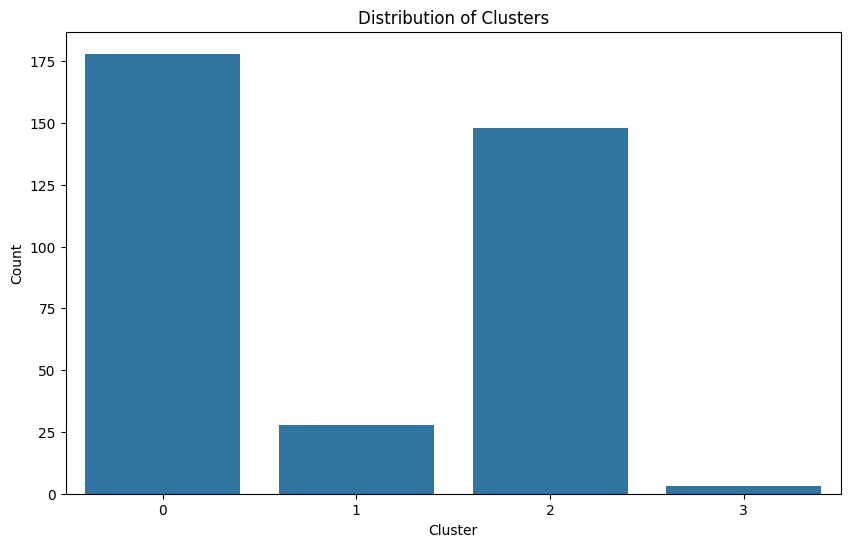

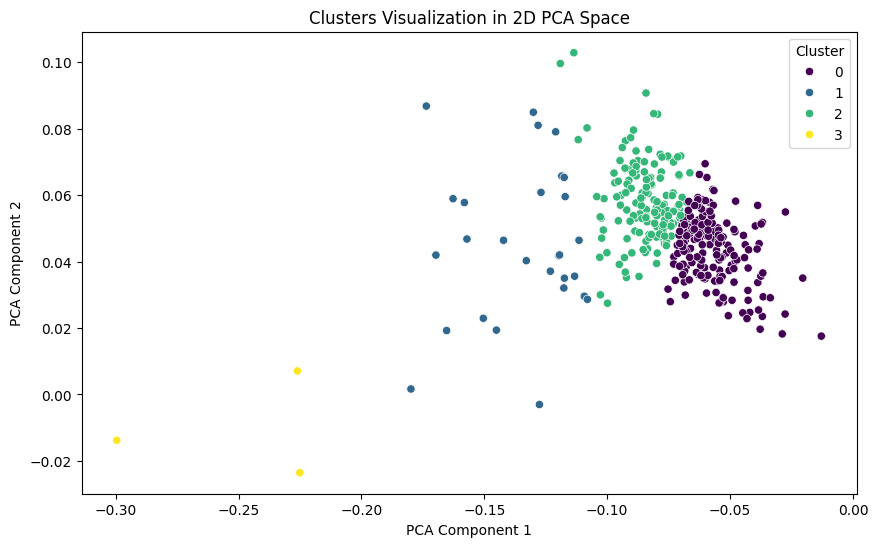

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clustered_pd = df_clustered.select("title", "pca_features", "prediction").toPandas()

pca_features = np.array(df_clustered_pd["pca_features"].tolist())
clusters = df_clustered_pd["prediction"]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=clusters, cmap='viridis', s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('PCA-reduced data points colored by cluster assignment')
plt.xlabel('PCA Feature 1')
plt.ylabel('PCA Feature 2')
plt.show()

plt.figure(figsize=(12, 8))
sns.countplot(x=clusters)
plt.title('Distribution of Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Papers')
plt.show()
